# Notebook para correr instancias y escalamiento del modelo:
#### Eduardo Carrasco Vidal - 22 junio 2026 - Estudiante Doctorado en Ingeniería de Sistemas Complejos

In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib
import pulp
import sys
import os
import platform

print("Computational Environment")
print("Python:", sys.version)
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("PuLP:", pulp.__version__)

Computational Environment
Python: 3.11.3 (main, Apr 19 2023, 18:49:55) [Clang 14.0.6 ]
Platform: macOS-26.5.2-arm64-arm-64bit
NumPy: 1.26.4
Pandas: 3.0.3
SciPy: 1.10.1
Matplotlib: 3.7.1
PuLP: 2.8.0


In [2]:
# ============================================================
# 01. IMPORTS AND GLOBAL CONFIGURATION
# ============================================================

import math
import time
import os
from pathlib import Path
from collections import deque, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import coo_matrix

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

# ============================================================
# GLOBAL PARAMETERS
# ============================================================

DEFAULT_PARAMS = {
    "SERVICE_TIME": 6.0,
    "RECOVERY_TIME": 2.0,
    "TMAX": 200.0,
    "ALPHA": 0.1,
    "TIME_UNIT": 1.0,
    "ZERO_BENEFIT_TOL": 0.0,
    "EFFECTIVE_BENEFIT_THRESHOLD": 1e-3,
}

OUTPUT_DIR = Path("ttap_experiments_inicial")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# FIGURE OUTPUT DIRECTORY
# ============================================================

FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_current_figure(save_name=None, dpi=300):
    """
    Guarda la figura actual si se entrega un nombre.
    Ejemplo:
        save_name="benefit_mean_std.png"
    """
    if save_name is None:
        return

    save_path = FIGURES_DIR / save_name

    plt.savefig(
        save_path,
        dpi=dpi,
        bbox_inches="tight"
    )

    print(f"Figure saved at: {save_path}")

In [3]:
# ============================================================
# 02. SCENARIO GENERATION
# ============================================================

def default_nodes():
    return {
        "Base": (0.0, 0.0),
        "A": (10.0, 5.0),
        "B": (20.0, 15.0),
        "C": (30.0, 10.0),
        "D": (40.0, 20.0),
    }


def default_fleet():
    return {
        "H1": {"visual": True,  "load": 500, "med": 3, "pers": 3, "speed": 150},
        "H2": {"visual": False, "load": 500, "med": 3, "pers": 3, "speed": 120},
        "H3": {"visual": True,  "load": 500, "med": 3, "pers": 3, "speed": 140},
        "H4": {"visual": False, "load": 500, "med": 3, "pers": 3, "speed": 160},
    }


def base_task_rows():
    # task_id, visual_required, load, med, pers, t_opt, t_eff, t_ineff
    return [
        (1,  True,  200, 2, 1, 20, 40, 60),
        (2,  False, 300, 1, 2, 15, 30, 50),
        (3,  True,  100, 3, 0, 10, 25, 40),
        (4,  False, 200, 0, 3, 30, 50, 70),
        (5,  True,  150, 1, 1, 25, 45, 60),
        (6,  True,  100, 3, 0, 10, 25, 120),
        (7,  False, 400, 0, 3, 30, 50, 90),
        (8,  True,  150, 1, 1, 25, 45, 100),
        (9,  True,  200, 2, 1, 20, 40, 60),
        (10, False, 300, 1, 2, 15, 30, 50),
        (11, True,  100, 3, 0, 10, 25, 40),
        (12, False, 200, 0, 3, 30, 50, 70),
        (13, True,  150, 1, 1, 25, 45, 60),
        (14, True,  100, 3, 0, 10, 25, 120),
        (15, False, 400, 0, 3, 30, 50, 90),
        (16, True,  150, 1, 1, 25, 45, 100),
        (17, True,  150, 1, 1, 25, 45, 60),
        (18, True,  100, 3, 0, 10, 25, 120),
        (19, False, 400, 0, 3, 30, 50, 90),
        (20, True,  150, 1, 1, 25, 45, 100),
    ]


def base_task_to_node():
    task_to_node = {}

    for i in [1, 2, 9, 10]:
        task_to_node[i] = "A"

    for i in [3, 8, 7, 11, 12, 13, 14]:
        task_to_node[i] = "B"

    for i in [5, 6, 15, 16]:
        task_to_node[i] = "C"

    for i in [4, 17, 18, 19, 20]:
        task_to_node[i] = "D"

    return task_to_node


def build_tasks_from_rows(task_rows):
    tasks = {}

    for row in task_rows:
        task_id, visual, load, med, pers, t_opt, t_eff, t_ineff = row

        tasks[int(task_id)] = {
            "visual": bool(visual),
            "load": int(load),
            "med": int(med),
            "pers": int(pers),
            "t_opt": float(t_opt),
            "t_eff": float(t_eff),
            "t_ineff": float(t_ineff),
        }

    return tasks


def generate_scaled_tasks(n_tasks=20, seed=1):
    """
    Genera tareas sintéticas escalables manteniendo los patrones del caso base.

    Para n_tasks = 20:
        usa exactamente las 20 tareas base.

    Para n_tasks > 20:
        replica patrones de tareas base con pequeñas variaciones controladas.
    """

    rng = np.random.default_rng(seed)

    base_rows = base_task_rows()
    base_assignment = base_task_to_node()

    if n_tasks <= 20:
        selected_rows = base_rows[:n_tasks]
        selected_tasks = build_tasks_from_rows(selected_rows)
        selected_task_to_node = {
            task_id: base_assignment[task_id]
            for task_id in selected_tasks
        }
        return selected_tasks, selected_task_to_node

    tasks = build_tasks_from_rows(base_rows)
    task_to_node = dict(base_assignment)

    node_choices = ["A", "B", "C", "D"]

    for new_id in range(21, n_tasks + 1):
        template = base_rows[(new_id - 1) % len(base_rows)]

        _, visual, load, med, pers, t_opt, t_eff, t_ineff = template

        # Pequeña variación temporal para que las instancias no sean clones exactos.
        jitter = int(rng.integers(-5, 6))

        new_t_opt = max(5, t_opt + jitter)
        new_t_eff = max(new_t_opt + 5, t_eff + jitter)
        new_t_ineff = max(new_t_eff + 10, t_ineff + jitter)

        tasks[new_id] = {
            "visual": bool(visual),
            "load": int(load),
            "med": int(med),
            "pers": int(pers),
            "t_opt": float(new_t_opt),
            "t_eff": float(new_t_eff),
            "t_ineff": float(new_t_ineff),
        }

        task_to_node[new_id] = rng.choice(node_choices).item()

    return tasks, task_to_node


def create_scenario(
    n_tasks=20,
    seed=1,
    scenario_id=None,
    params=None,
):
    """
    Crea un escenario completo TTAP.
    """

    if scenario_id is None:
        scenario_id = f"default_nodes_{n_tasks}_tasks_seed_{seed}"

    if params is None:
        params = DEFAULT_PARAMS.copy()
    else:
        new_params = DEFAULT_PARAMS.copy()
        new_params.update(params)
        params = new_params

    tasks, task_to_node = generate_scaled_tasks(
        n_tasks=n_tasks,
        seed=seed
    )

    scenario = {
        "scenario_id": scenario_id,
        "seed": seed,
        "nodes": default_nodes(),
        "helicopters": default_fleet(),
        "tasks": tasks,
        "task_to_node": task_to_node,
        "params": params,
    }

    return scenario


# Test rápido de escenario base
scenario_20 = create_scenario(n_tasks=20, seed=1)
print(scenario_20["scenario_id"])
print("Nodos:", len(scenario_20["nodes"]))
print("Tareas:", len(scenario_20["tasks"]))
print("Helicópteros:", len(scenario_20["helicopters"]))

default_nodes_20_tasks_seed_1
Nodos: 5
Tareas: 20
Helicópteros: 4


In [4]:
# ============================================================
# 03. COMMON FUNCTIONS
# ============================================================

def helo_to_int(h):
    if isinstance(h, str):
        h = h.strip()
        if h.startswith("H"):
            return int(h.replace("H", ""))
        return int(h)
    return int(h)


def euclidean_distance(scenario, node_a, node_b):
    nodes = scenario["nodes"]

    xa, ya = nodes[node_a]
    xb, yb = nodes[node_b]

    return math.hypot(xa - xb, ya - yb)


def travel_time_minutes(scenario, h, node_a, node_b):
    if node_a == node_b:
        return 0.0

    distance = euclidean_distance(scenario, node_a, node_b)
    speed = scenario["helicopters"][h]["speed"]

    return 60.0 * distance / speed


def satisfaction(scenario, t, task):
    alpha = scenario["params"]["ALPHA"]

    if t <= task["t_opt"]:
        return 1.0

    if t >= task["t_ineff"]:
        return 0.0

    return 1.0 / (1.0 + math.exp(alpha * (t - task["t_eff"])))


def task_benefit(scenario, task_id, finish_time):
    tasks = scenario["tasks"]

    return satisfaction(
        scenario,
        finish_time,
        tasks[task_id]
    ) / len(tasks)


def can_execute_task_by_resources(scenario, h, task_id, load, med, pers):
    helo = scenario["helicopters"][h]
    task = scenario["tasks"][task_id]

    if task["visual"] and not helo["visual"]:
        return False

    if load < task["load"]:
        return False

    if med < task["med"]:
        return False

    if pers < task["pers"]:
        return False

    return True


def ceil_steps(minutes, time_unit):
    return int(math.ceil((minutes - 1e-9) / time_unit))


def time_from_step(k, time_unit):
    return k * time_unit


def make_state(node, k, load, med, pers):
    return (node, int(k), int(load), int(med), int(pers))


def start_state(scenario, h):
    p = scenario["helicopters"][h]

    return make_state(
        "Base",
        0,
        p["load"],
        p["med"],
        p["pers"],
    )


def sink_state():
    return ("SINK", -1, 0, 0, 0)

In [5]:
# ============================================================
# 04. GREEDY TTAP
# ============================================================

def solve_greedy_ttap(
    scenario,
    discretize_time=True,
    verbose=False,
):
    """
    Heurística greedy:
    - selecciona el helicóptero disponible más temprano;
    - evalúa tareas pendientes factibles;
    - elige la tarea con mayor beneficio inmediato;
    - si no puede ejecutar tareas, retorna a base para recuperar;
    - si está en base y no puede ejecutar nada, queda bloqueado.
    """

    t0 = time.time()

    params = scenario["params"]
    tasks = scenario["tasks"]
    task_to_node = scenario["task_to_node"]
    helicopters = scenario["helicopters"]

    service_time = params["SERVICE_TIME"]
    recovery_time = params["RECOVERY_TIME"]
    tmax = params["TMAX"]
    time_unit = params["TIME_UNIT"]
    zero_tol = params["ZERO_BENEFIT_TOL"]

    helo_state = {}

    for h, p in helicopters.items():
        helo_state[h] = {
            "node": "Base",
            "available_time": 0.0,
            "load": p["load"],
            "med": p["med"],
            "pers": p["pers"],
            "blocked": False,
        }

    pending = set(tasks.keys())

    total_benefit = 0.0
    rows = []

    while pending:
        active_helos = [
            h for h in helicopters
            if not helo_state[h]["blocked"]
        ]

        if not active_helos:
            break

        h = min(
            active_helos,
            key=lambda hh: helo_state[hh]["available_time"]
        )

        h_state = helo_state[h]

        if h_state["available_time"] >= tmax:
            h_state["blocked"] = True
            continue

        current_node = h_state["node"]
        current_time = h_state["available_time"]

        best_task = None
        best_node = None
        best_benefit = zero_tol
        best_flight = 0.0
        best_finish = 0.0

        for task_id in sorted(pending):
            if not can_execute_task_by_resources(
                scenario,
                h,
                task_id,
                h_state["load"],
                h_state["med"],
                h_state["pers"],
            ):
                continue

            task_node = task_to_node[task_id]
            flight = travel_time_minutes(
                scenario,
                h,
                current_node,
                task_node,
            )

            duration = flight + service_time

            if discretize_time:
                k_now = int(round(current_time / time_unit))
                k_finish = k_now + ceil_steps(duration, time_unit)
                finish_time = time_from_step(k_finish, time_unit)
            else:
                finish_time = current_time + duration

            if finish_time > tmax:
                continue

            benefit = task_benefit(scenario, task_id, finish_time)

            if benefit <= zero_tol:
                continue

            # Regla greedy: mayor beneficio inmediato.
            # En empate, menor tiempo de término.
            if (
                benefit > best_benefit
                or (
                    math.isclose(benefit, best_benefit)
                    and best_task is not None
                    and finish_time < best_finish
                )
            ):
                best_task = task_id
                best_node = task_node
                best_benefit = benefit
                best_flight = flight
                best_finish = finish_time

        if best_task is not None:
            task = tasks[best_task]

            h_state["node"] = best_node
            h_state["available_time"] = best_finish
            h_state["load"] -= task["load"]
            h_state["med"] -= task["med"]
            h_state["pers"] -= task["pers"]

            pending.remove(best_task)
            total_benefit += best_benefit

            rows.append({
                "Scenario": scenario["scenario_id"],
                "Method": "Greedy",
                "Helo ID": helo_to_int(h),
                "Task ID": best_task,
                "Node": best_node,
                "Flight Time": best_flight,
                "Service Time": service_time,
                "Total Task Time": best_flight + service_time,
                "Completion Time": best_finish,
                "Benefit": best_benefit,
                "Remaining Load": h_state["load"],
                "Remaining Medical": h_state["med"],
                "Remaining Personnel": h_state["pers"],
                "Status": "Task Executed",
            })

            if verbose:
                print(
                    f"{h} → T{best_task} "
                    f"fin={best_finish:.1f}' ΔB={best_benefit:.6f}"
                )

        else:
            # Si no encuentra tarea, intenta retornar a base.
            if current_node != "Base":
                flight = travel_time_minutes(
                    scenario,
                    h,
                    current_node,
                    "Base",
                )

                duration = flight + recovery_time

                if discretize_time:
                    k_now = int(round(current_time / time_unit))
                    k_finish = k_now + ceil_steps(duration, time_unit)
                    finish_time = time_from_step(k_finish, time_unit)
                else:
                    finish_time = current_time + duration

                p = helicopters[h]

                h_state["node"] = "Base"
                h_state["available_time"] = finish_time
                h_state["load"] = p["load"]
                h_state["med"] = p["med"]
                h_state["pers"] = p["pers"]

                rows.append({
                    "Scenario": scenario["scenario_id"],
                    "Method": "Greedy",
                    "Helo ID": helo_to_int(h),
                    "Task ID": "Idle",
                    "Node": "Base",
                    "Flight Time": flight,
                    "Service Time": recovery_time,
                    "Total Task Time": flight + recovery_time,
                    "Completion Time": finish_time,
                    "Benefit": 0.0,
                    "Remaining Load": h_state["load"],
                    "Remaining Medical": h_state["med"],
                    "Remaining Personnel": h_state["pers"],
                    "Status": "Idle",
                })

                if verbose:
                    print(f"{h} → Base to recover")

            else:
                h_state["blocked"] = True

    runtime = time.time() - t0

    df = pd.DataFrame(rows)

    completed = sorted(
        df[df["Status"] == "Task Executed"]["Task ID"].astype(int).tolist()
    ) if not df.empty else []

    summary = {
        "Scenario": scenario["scenario_id"],
        "Method": "Greedy",
        "Accumulated Benefit": total_benefit,
        "Completed Tasks": len(completed),
        "Uncompleted Tasks": sorted(set(tasks.keys()) - set(completed)),
        "Runtime sec": runtime,
        "Optimal Certified": False,
        "MIP Gap": np.nan,
        "Variables": np.nan,
        "Constraints": np.nan,
        "Nonzeros": np.nan,
    }

    return df, summary

In [6]:
# ============================================================
# 05. EXACT TTAP MILP - STATE-SPACE NETWORK
# ============================================================

def build_state_graph_for_helicopter(scenario, h):
    params = scenario["params"]
    tasks = scenario["tasks"]
    task_to_node = scenario["task_to_node"]
    helicopters = scenario["helicopters"]

    service_time = params["SERVICE_TIME"]
    recovery_time = params["RECOVERY_TIME"]
    tmax = params["TMAX"]
    time_unit = params["TIME_UNIT"]
    zero_tol = params["ZERO_BENEFIT_TOL"]

    tmax_steps = int(round(tmax / time_unit))

    s0 = start_state(scenario, h)
    sink = sink_state()

    states = set([s0])
    queue = deque([s0])
    arcs = []

    while queue:
        current_state = queue.popleft()

        node, k, load, med, pers = current_state
        current_time = time_from_step(k, time_unit)

        # -----------------------------
        # Task arcs
        # -----------------------------
        for task_id in sorted(tasks.keys()):
            if not can_execute_task_by_resources(
                scenario,
                h,
                task_id,
                load,
                med,
                pers,
            ):
                continue

            task_node = task_to_node[task_id]

            flight = travel_time_minutes(
                scenario,
                h,
                node,
                task_node,
            )

            duration = flight + service_time
            duration_steps = ceil_steps(duration, time_unit)

            k_new = k + duration_steps

            if k_new > tmax_steps:
                continue

            finish_time = time_from_step(k_new, time_unit)

            task = tasks[task_id]

            new_state = make_state(
                task_node,
                k_new,
                load - task["load"],
                med - task["med"],
                pers - task["pers"],
            )

            benefit = task_benefit(
                scenario,
                task_id,
                finish_time,
            )

            if benefit <= zero_tol:
                continue

            arcs.append({
                "h": h,
                "from": current_state,
                "to": new_state,
                "kind": "task",
                "task": task_id,
                "start_time": current_time,
                "finish_time": finish_time,
                "flight_time": flight,
                "service_time": service_time,
                "benefit": benefit,
            })

            if new_state not in states:
                states.add(new_state)
                queue.append(new_state)

        # -----------------------------
        # Return-to-base arc
        # -----------------------------
        if node != "Base":
            flight = travel_time_minutes(
                scenario,
                h,
                node,
                "Base",
            )

            duration = flight + recovery_time
            duration_steps = ceil_steps(duration, time_unit)

            k_new = k + duration_steps

            if k_new <= tmax_steps:
                p = helicopters[h]

                new_state = make_state(
                    "Base",
                    k_new,
                    p["load"],
                    p["med"],
                    p["pers"],
                )

                arcs.append({
                    "h": h,
                    "from": current_state,
                    "to": new_state,
                    "kind": "return",
                    "task": None,
                    "start_time": current_time,
                    "finish_time": time_from_step(k_new, time_unit),
                    "flight_time": flight,
                    "service_time": recovery_time,
                    "benefit": 0.0,
                })

                if new_state not in states:
                    states.add(new_state)
                    queue.append(new_state)

    # -----------------------------
    # End arcs
    # -----------------------------
    states.add(sink)

    for s in list(states):
        if s == sink:
            continue

        node, k, load, med, pers = s

        arcs.append({
            "h": h,
            "from": s,
            "to": sink,
            "kind": "end",
            "task": None,
            "start_time": time_from_step(k, time_unit),
            "finish_time": time_from_step(k, time_unit),
            "flight_time": 0.0,
            "service_time": 0.0,
            "benefit": 0.0,
        })

    return list(states), arcs


def build_full_exact_graph(scenario, verbose=False):
    states_by_h = {}
    arcs_by_h = {}
    all_arcs = []

    for h in scenario["helicopters"]:
        states, arcs = build_state_graph_for_helicopter(scenario, h)

        states_by_h[h] = states
        arcs_by_h[h] = arcs
        all_arcs.extend(arcs)

        if verbose:
            print(f"{h}: {len(states):,} states | {len(arcs):,} arcs")

    if verbose:
        print(f"Total arcs / binary variables: {len(all_arcs):,}")

    return states_by_h, arcs_by_h, all_arcs


def build_exact_milp_matrices(scenario, states_by_h, arcs_by_h, all_arcs):
    helicopters = scenario["helicopters"]
    tasks = scenario["tasks"]

    n_vars = len(all_arcs)

    c = np.array(
        [-arc["benefit"] for arc in all_arcs],
        dtype=float
    )

    lb = np.zeros(n_vars)
    ub = np.ones(n_vars)
    integrality = np.ones(n_vars, dtype=int)

    row_idx = []
    col_idx = []
    vals = []

    rhs_lb = []
    rhs_ub = []

    current_row = 0

    arc_global_index = {}
    offset = 0

    for h in helicopters:
        for local_idx, arc in enumerate(arcs_by_h[h]):
            arc_global_index[(h, local_idx)] = offset + local_idx
        offset += len(arcs_by_h[h])

    # -----------------------------
    # Flow conservation
    # -----------------------------
    for h in helicopters:
        outgoing = defaultdict(list)
        incoming = defaultdict(list)

        for local_idx, arc in enumerate(arcs_by_h[h]):
            j = arc_global_index[(h, local_idx)]
            outgoing[arc["from"]].append(j)
            incoming[arc["to"]].append(j)

        s0 = start_state(scenario, h)
        sink = sink_state()

        for state in states_by_h[h]:
            for j in outgoing.get(state, []):
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(1.0)

            for j in incoming.get(state, []):
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(-1.0)

            if state == s0:
                rhs = 1.0
            elif state == sink:
                rhs = -1.0
            else:
                rhs = 0.0

            rhs_lb.append(rhs)
            rhs_ub.append(rhs)

            current_row += 1

    # -----------------------------
    # Each task at most once
    # -----------------------------
    for task_id in tasks:
        for j, arc in enumerate(all_arcs):
            if arc["kind"] == "task" and arc["task"] == task_id:
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(1.0)

        rhs_lb.append(-np.inf)
        rhs_ub.append(1.0)

        current_row += 1

    A = coo_matrix(
        (vals, (row_idx, col_idx)),
        shape=(current_row, n_vars)
    ).tocsr()

    constraints = LinearConstraint(
        A,
        np.array(rhs_lb, dtype=float),
        np.array(rhs_ub, dtype=float),
    )

    bounds = Bounds(lb, ub)

    return c, integrality, bounds, constraints, A


def solve_exact_ttap_highs(
    scenario,
    time_limit=180,
    mip_rel_gap=1e-6,
    verbose=False,
):
    t0 = time.time()

    states_by_h, arcs_by_h, all_arcs = build_full_exact_graph(
        scenario,
        verbose=verbose,
    )

    c, integrality, bounds, constraints, A = build_exact_milp_matrices(
        scenario,
        states_by_h,
        arcs_by_h,
        all_arcs,
    )

    result = milp(
        c=c,
        integrality=integrality,
        bounds=bounds,
        constraints=constraints,
        options={
            "time_limit": time_limit,
            "mip_rel_gap": mip_rel_gap,
            "disp": verbose,
        },
    )

    runtime = time.time() - t0

    if result.x is None:
        return None, None, {
            "Scenario": scenario["scenario_id"],
            "Method": "Exact-HiGHS",
            "Accumulated Benefit": np.nan,
            "Completed Tasks": np.nan,
            "Uncompleted Tasks": None,
            "Runtime sec": runtime,
            "Optimal Certified": False,
            "MIP Gap": getattr(result, "mip_gap", np.nan),
            "Variables": len(all_arcs),
            "Constraints": A.shape[0],
            "Nonzeros": A.nnz,
            "Solver Message": result.message,
        }

    objective_value = -result.fun

    mip_gap = 0.0 if result.success else getattr(result, "mip_gap", np.nan)

    summary = {
        "Scenario": scenario["scenario_id"],
        "Method": "Exact-HiGHS",
        "Accumulated Benefit": objective_value,
        "Completed Tasks": None,
        "Uncompleted Tasks": None,
        "Runtime sec": runtime,
        "Optimal Certified": bool(result.success),
        "MIP Gap": mip_gap,
        "Variables": len(all_arcs),
        "Constraints": A.shape[0],
        "Nonzeros": A.nnz,
        "Solver Message": result.message,
    }

    exact_package = {
        "result": result,
        "all_arcs": all_arcs,
        "states_by_h": states_by_h,
        "arcs_by_h": arcs_by_h,
        "A": A,
    }

    return result, exact_package, summary


def decode_exact_solution(scenario, result, all_arcs):
    selected_indices = [
        j for j, value in enumerate(result.x)
        if value > 0.5
    ]

    selected_arcs = [all_arcs[j] for j in selected_indices]

    selected_by_h = defaultdict(list)

    for arc in selected_arcs:
        selected_by_h[arc["h"]].append(arc)

    rows = []

    for h in scenario["helicopters"]:
        out_arc = {
            arc["from"]: arc
            for arc in selected_by_h[h]
        }

        current = start_state(scenario, h)

        while True:
            arc = out_arc.get(current)

            if arc is None:
                break

            if arc["kind"] == "end":
                break

            if arc["kind"] == "task":
                task_id = arc["task"]
                next_state = arc["to"]

                rows.append({
                    "Scenario": scenario["scenario_id"],
                    "Method": "Exact-HiGHS",
                    "Helo ID": helo_to_int(h),
                    "Task ID": task_id,
                    "Node": scenario["task_to_node"][task_id],
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Completion Time": arc["finish_time"],
                    "Benefit": arc["benefit"],
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Task Executed",
                })

            elif arc["kind"] == "return":
                next_state = arc["to"]

                rows.append({
                    "Scenario": scenario["scenario_id"],
                    "Method": "Exact-HiGHS",
                    "Helo ID": helo_to_int(h),
                    "Task ID": "Idle",
                    "Node": "Base",
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Completion Time": arc["finish_time"],
                    "Benefit": 0.0,
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Idle",
                })

            current = arc["to"]

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df.sort_values(
            by=["Completion Time", "Helo ID"]
        ).reset_index(drop=True)

    return df

In [8]:
# ============================================================
# 06. METRICS
# ============================================================

def gini_coefficient(values):
    values = np.array(values, dtype=float)

    if len(values) == 0:
        return np.nan

    if np.all(values == 0):
        return 0.0

    values = np.sort(values)
    n = len(values)
    cumulative = np.cumsum(values)

    return (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n


def compute_ttap_metrics(
    scenario,
    df,
    method_name,
    runtime_sec=None,
    optimal=False,
    mip_gap=np.nan,
    variables=np.nan,
    constraints=np.nan,
    nonzeros=np.nan,
    exact_benefit_reference=None,
):
    tasks = scenario["tasks"]
    threshold = scenario["params"]["EFFECTIVE_BENEFIT_THRESHOLD"]

    if df is None or df.empty:
        return {
            "Scenario": scenario["scenario_id"],
            "Tasks": len(tasks),
            "Method": method_name,
            "Accumulated Benefit": 0.0,
            "Optimality Gap vs Exact": np.nan,
            "Physical Completed Tasks": 0,
            "Physical Completion Rate": 0.0,
            "Positive Benefit Tasks": 0,
            "Operationally Relevant Tasks": 0,
            "Average Response Time": np.nan,
            "Maximum Response Time": np.nan,
            "Makespan": 0.0,
            "Total Flight Time": 0.0,
            "Operational Cost Proxy": 0.0,
            "Runtime sec": runtime_sec,
            "Optimal Certified": optimal,
            "MIP Gap": mip_gap,
            "Variables": variables,
            "Constraints": constraints,
            "Nonzeros": nonzeros,
        }

    df = df.copy()
    df["Helo ID"] = df["Helo ID"].apply(helo_to_int)

    task_df = df[df["Status"] == "Task Executed"].copy()
    idle_df = df[df["Status"] != "Task Executed"].copy()

    total_tasks = len(tasks)

    accumulated_benefit = task_df["Benefit"].sum() if not task_df.empty else 0.0

    physical_completed = task_df["Task ID"].nunique() if not task_df.empty else 0

    positive_task_df = task_df[task_df["Benefit"] > 0.0].copy()
    positive_completed = positive_task_df["Task ID"].nunique()

    relevant_task_df = task_df[task_df["Benefit"] > threshold].copy()
    relevant_completed = relevant_task_df["Task ID"].nunique()

    avg_response_time = task_df["Completion Time"].mean() if not task_df.empty else np.nan
    max_response_time = task_df["Completion Time"].max() if not task_df.empty else np.nan

    makespan = df["Completion Time"].max() if not df.empty else 0.0

    total_task_flight = task_df["Flight Time"].sum() if not task_df.empty else 0.0
    total_return_flight = idle_df["Flight Time"].sum() if not idle_df.empty else 0.0
    total_flight = total_task_flight + total_return_flight

    total_task_service = task_df["Service Time"].sum() if not task_df.empty else 0.0
    total_recovery = idle_df["Service Time"].sum() if not idle_df.empty else 0.0

    productive_time = total_task_flight + total_task_service
    active_time = productive_time + total_return_flight + total_recovery

    fleet_size = len(scenario["helicopters"])
    total_available_fleet_time = fleet_size * makespan if makespan > 0 else np.nan

    productive_utilization = (
        productive_time / total_available_fleet_time
        if total_available_fleet_time and total_available_fleet_time > 0
        else np.nan
    )

    active_utilization = (
        active_time / total_available_fleet_time
        if total_available_fleet_time and total_available_fleet_time > 0
        else np.nan
    )

    operational_cost_proxy = total_flight + total_recovery

    task_counts = []
    workloads = []

    for h in sorted(df["Helo ID"].unique()):
        h_df = df[df["Helo ID"] == h]
        h_task_df = h_df[h_df["Status"] == "Task Executed"]

        task_counts.append(len(h_task_df))
        workloads.append(h_df["Total Task Time"].sum())

    if exact_benefit_reference is not None and exact_benefit_reference > 0:
        gap_vs_exact = (exact_benefit_reference - accumulated_benefit) / exact_benefit_reference
    else:
        gap_vs_exact = np.nan

    return {
        "Scenario": scenario["scenario_id"],
        "Tasks": total_tasks,
        "Method": method_name,
        "Accumulated Benefit": accumulated_benefit,
        "Optimality Gap vs Exact": gap_vs_exact,
        "Physical Completed Tasks": physical_completed,
        "Physical Completion Rate": physical_completed / total_tasks,
        "Positive Benefit Tasks": positive_completed,
        "Positive Benefit Completion Rate": positive_completed / total_tasks,
        "Operationally Relevant Tasks": relevant_completed,
        "Operationally Relevant Completion Rate": relevant_completed / total_tasks,
        "Average Response Time": avg_response_time,
        "Maximum Response Time": max_response_time,
        "Makespan": makespan,
        "Productive Time": productive_time,
        "Active Time": active_time,
        "Productive Utilization": productive_utilization,
        "Active Utilization": active_utilization,
        "Total Task Flight Time": total_task_flight,
        "Total Return Flight Time": total_return_flight,
        "Total Flight Time": total_flight,
        "Total Recovery Time": total_recovery,
        "Operational Cost Proxy": operational_cost_proxy,
        "Task Count Std": np.std(task_counts) if len(task_counts) > 0 else np.nan,
        "Task Count Gini": gini_coefficient(task_counts),
        "Workload Std": np.std(workloads) if len(workloads) > 0 else np.nan,
        "Workload Gini": gini_coefficient(workloads),
        "Runtime sec": runtime_sec,
        "Optimal Certified": optimal,
        "MIP Gap": mip_gap,
        "Variables": variables,
        "Constraints": constraints,
        "Nonzeros": nonzeros,
    }

In [9]:
# ============================================================
# 07. EXPERIMENT RUNNER
# ============================================================

def run_single_scenario(
    scenario,
    run_exact=True,
    exact_time_limit=180,
    exact_mip_gap=1e-6,
    verbose=False,
):
    """
    Corre Greedy y opcionalmente Exact-HiGHS sobre un escenario.
    """

    # -----------------------------
    # Greedy
    # -----------------------------
    df_greedy, greedy_summary = solve_greedy_ttap(
        scenario,
        discretize_time=True,
        verbose=verbose,
    )

    # -----------------------------
    # Exact
    # -----------------------------
    df_exact = None
    exact_summary = None
    exact_package = None

    if run_exact:
        result_exact, exact_package, exact_summary = solve_exact_ttap_highs(
            scenario,
            time_limit=exact_time_limit,
            mip_rel_gap=exact_mip_gap,
            verbose=verbose,
        )

        if result_exact is not None:
            df_exact = decode_exact_solution(
                scenario,
                result_exact,
                exact_package["all_arcs"],
            )

            completed_exact = sorted(
                df_exact[df_exact["Status"] == "Task Executed"]["Task ID"]
                .astype(int)
                .tolist()
            ) if not df_exact.empty else []

            exact_summary["Completed Tasks"] = len(completed_exact)
            exact_summary["Uncompleted Tasks"] = sorted(
                set(scenario["tasks"].keys()) - set(completed_exact)
            )

    exact_benefit_reference = (
        exact_summary["Accumulated Benefit"]
        if exact_summary is not None
        else None
    )

    # -----------------------------
    # Metrics
    # -----------------------------
    greedy_metrics = compute_ttap_metrics(
        scenario,
        df_greedy,
        method_name="Greedy",
        runtime_sec=greedy_summary["Runtime sec"],
        optimal=False,
        mip_gap=np.nan,
        exact_benefit_reference=exact_benefit_reference,
    )

    metrics = [greedy_metrics]

    if run_exact and exact_summary is not None and df_exact is not None:
        exact_metrics = compute_ttap_metrics(
            scenario,
            df_exact,
            method_name="Exact-HiGHS",
            runtime_sec=exact_summary["Runtime sec"],
            optimal=exact_summary["Optimal Certified"],
            mip_gap=exact_summary["MIP Gap"],
            variables=exact_summary["Variables"],
            constraints=exact_summary["Constraints"],
            nonzeros=exact_summary["Nonzeros"],
            exact_benefit_reference=exact_benefit_reference,
        )

        metrics.append(exact_metrics)

    df_metrics = pd.DataFrame(metrics)

    return {
        "scenario": scenario,
        "df_greedy": df_greedy,
        "df_exact": df_exact,
        "greedy_summary": greedy_summary,
        "exact_summary": exact_summary,
        "metrics": df_metrics,
        "exact_package": exact_package,
    }


def run_experiment_suite(
    task_sizes,
    seeds,
    exact_max_tasks=60,
    exact_time_limit=180,
    exact_mip_gap=1e-6,
    verbose=False,
):
    """
    Ejecuta un conjunto de escenarios escalados.
    """

    all_metrics = []
    all_task_logs = []

    for n_tasks in task_sizes:
        for seed in seeds:
            scenario = create_scenario(
                n_tasks=n_tasks,
                seed=seed,
                scenario_id=f"default_nodes_T{n_tasks}_S{seed}",
            )

            run_exact = n_tasks <= exact_max_tasks

            print(
                f"\nRunning scenario {scenario['scenario_id']} "
                f"| exact={run_exact}"
            )

            result = run_single_scenario(
                scenario,
                run_exact=run_exact,
                exact_time_limit=exact_time_limit,
                exact_mip_gap=exact_mip_gap,
                verbose=verbose,
            )

            df_metrics = result["metrics"]
            all_metrics.append(df_metrics)

            if result["df_greedy"] is not None:
                all_task_logs.append(result["df_greedy"])

            if result["df_exact"] is not None:
                all_task_logs.append(result["df_exact"])

    df_all_metrics = pd.concat(all_metrics, ignore_index=True)

    df_all_logs = (
        pd.concat(all_task_logs, ignore_index=True)
        if all_task_logs
        else pd.DataFrame()
    )

    return df_all_metrics, df_all_logs

In [10]:
# ============================================================
# 08. BASE SCENARIO TEST
# ============================================================

scenario_20 = create_scenario(
    n_tasks=20,
    seed=1,
    scenario_id="baseline_20_tasks"
)

result_20 = run_single_scenario(
    scenario_20,
    run_exact=True,
    exact_time_limit=300,
    exact_mip_gap=1e-6,
    verbose=False,
)

display(result_20["metrics"])

print("\nGreedy route:")
display(result_20["df_greedy"])

print("\nExact route:")
display(result_20["df_exact"])

,Scenario,Tasks,Method,Accumulated Benefit,Optimality Gap vs Exact,Physical Completed Tasks,Physical Completion Rate,Positive Benefit Tasks,Positive Benefit Completion Rate,Operationally Relevant Tasks,Operationally Relevant Completion Rate,Average Response Time,Maximum Response Time,Makespan,Productive Time,Active Time,Productive Utilization,Active Utilization,Total Task Flight Time,Total Return Flight Time,Total Flight Time,Total Recovery Time,Operational Cost Proxy,Task Count Std,Task Count Gini,Workload Std,Workload Gini,Runtime sec,Optimal Certified,MIP Gap,Variables,Constraints,Nonzeros
0,baseline_20_tasks,20,Greedy,0.429819,7.464728e-02,16,0.8,16,0.8,15,0.75,44.875,91.0,108.0,230.033111,385.351791,0.532484,0.892018,134.033111,133.318680,267.351791,22.0,289.351791,1.000000,0.12500,7.733022,0.043958,0.000782,False,NaN,NaN,NaN,NaN
1,baseline_20_tasks,20,Exact-HiGHS,0.464492,-1.195094e-16,16,0.8,16,0.8,13,0.65,46.125,109.0,129.0,237.010282,381.408539,0.459322,0.739164,141.010282,124.398257,265.408539,20.0,285.408539,1.581139,0.21875,33.561411,0.185695,2.314151,True,0.0,7352.0,2141.0,18050.0



Greedy route:


,Scenario,Method,Helo ID,Task ID,Node,Flight Time,Service Time,Total Task Time,Completion Time,Benefit,Remaining Load,Remaining Medical,Remaining Personnel,Status
0,baseline_20_tasks,Greedy,1,1,A,4.472136,6.0,10.472136,11.0,0.050000,300,1,2,Task Executed
1,baseline_20_tasks,Greedy,2,2,A,5.590170,6.0,11.590170,12.0,0.050000,200,2,1,Task Executed
2,baseline_20_tasks,Greedy,3,9,A,4.791574,6.0,10.791574,11.0,0.050000,300,1,2,Task Executed
3,baseline_20_tasks,Greedy,4,10,A,4.192627,6.0,10.192627,11.0,0.050000,200,2,1,Task Executed
4,baseline_20_tasks,Greedy,1,8,B,5.656854,6.0,11.656854,23.0,0.050000,150,0,1,Task Executed
5,baseline_20_tasks,Greedy,3,13,B,6.060915,6.0,12.060915,24.0,0.050000,150,0,1,Task Executed
6,baseline_20_tasks,Greedy,4,Idle,Base,4.192627,2.0,6.192627,18.0,0.000000,500,3,3,Idle
7,baseline_20_tasks,Greedy,2,Idle,Base,5.590170,2.0,7.590170,20.0,0.000000,500,3,3,Idle
8,baseline_20_tasks,Greedy,4,7,B,9.375000,6.0,15.375000,34.0,0.041601,100,3,0,Task Executed
9,baseline_20_tasks,Greedy,2,12,B,12.500000,6.0,18.500000,39.0,0.037513,300,3,0,Task Executed



Exact route:


,Scenario,Method,Helo ID,Task ID,Node,Flight Time,Service Time,Total Task Time,Completion Time,Benefit,Remaining Load,Remaining Medical,Remaining Personnel,Status
0,baseline_20_tasks,Exact-HiGHS,3,2,A,4.791574,6.0,10.791574,11.0,0.050000,200,2,1,Task Executed
1,baseline_20_tasks,Exact-HiGHS,2,10,A,5.590170,6.0,11.590170,12.0,0.050000,200,2,1,Task Executed
2,baseline_20_tasks,Exact-HiGHS,4,12,B,9.375000,6.0,15.375000,16.0,0.050000,300,3,0,Task Executed
3,baseline_20_tasks,Exact-HiGHS,3,1,A,0.000000,6.0,6.000000,17.0,0.050000,0,0,0,Task Executed
4,baseline_20_tasks,Exact-HiGHS,1,16,C,12.649111,6.0,18.649111,19.0,0.050000,350,2,2,Task Executed
5,baseline_20_tasks,Exact-HiGHS,2,Idle,Base,5.590170,2.0,7.590170,20.0,0.000000,500,3,3,Idle
6,baseline_20_tasks,Exact-HiGHS,3,Idle,Base,4.791574,2.0,6.791574,24.0,0.000000,500,3,3,Idle
7,baseline_20_tasks,Exact-HiGHS,1,5,C,0.000000,6.0,6.000000,25.0,0.050000,200,1,1,Task Executed
8,baseline_20_tasks,Exact-HiGHS,4,Idle,Base,9.375000,2.0,11.375000,28.0,0.000000,500,3,3,Idle
9,baseline_20_tasks,Exact-HiGHS,1,17,D,5.656854,6.0,11.656854,37.0,0.034499,50,0,0,Task Executed


In [11]:
# ============================================================
# 09. INITIAL SCALING EXPERIMENT
# ============================================================

task_sizes = [20, 30, 40, 50, 60]
#seeds = [1, 2, 3]
seeds = list(range(1, 31))

df_metrics_scaling, df_logs_scaling = run_experiment_suite(
    task_sizes=task_sizes,
    seeds=seeds,
    exact_max_tasks=60,
    exact_time_limit=300,
    exact_mip_gap=1e-6,
    verbose=False,
)

display(df_metrics_scaling)

# Guardar resultados
df_metrics_scaling.to_csv(
    OUTPUT_DIR / "metrics_scaling_default_nodes.csv",
    index=False
)

df_logs_scaling.to_csv(
    OUTPUT_DIR / "task_logs_scaling_default_nodes.csv",
    index=False
)

print("Saved:")
print(OUTPUT_DIR / "metrics_scaling_default_nodes.csv")
print(OUTPUT_DIR / "task_logs_scaling_default_nodes.csv")


Running scenario default_nodes_T20_S1 | exact=True

Running scenario default_nodes_T20_S2 | exact=True

Running scenario default_nodes_T20_S3 | exact=True

Running scenario default_nodes_T20_S4 | exact=True

Running scenario default_nodes_T20_S5 | exact=True

Running scenario default_nodes_T20_S6 | exact=True

Running scenario default_nodes_T20_S7 | exact=True

Running scenario default_nodes_T20_S8 | exact=True

Running scenario default_nodes_T20_S9 | exact=True

Running scenario default_nodes_T20_S10 | exact=True

Running scenario default_nodes_T20_S11 | exact=True

Running scenario default_nodes_T20_S12 | exact=True

Running scenario default_nodes_T20_S13 | exact=True

Running scenario default_nodes_T20_S14 | exact=True

Running scenario default_nodes_T20_S15 | exact=True

Running scenario default_nodes_T20_S16 | exact=True

Running scenario default_nodes_T20_S17 | exact=True

Running scenario default_nodes_T20_S18 | exact=True

Running scenario default_nodes_T20_S19 | exact=True

R

,Scenario,Tasks,Method,Accumulated Benefit,Optimality Gap vs Exact,Physical Completed Tasks,Physical Completion Rate,Positive Benefit Tasks,Positive Benefit Completion Rate,Operationally Relevant Tasks,Operationally Relevant Completion Rate,Average Response Time,Maximum Response Time,Makespan,Productive Time,Active Time,Productive Utilization,Active Utilization,Total Task Flight Time,Total Return Flight Time,Total Flight Time,Total Recovery Time,Operational Cost Proxy,Task Count Std,Task Count Gini,Workload Std,Workload Gini,Runtime sec,Optimal Certified,MIP Gap,Variables,Constraints,Nonzeros
0,default_nodes_T20_S1,20,Greedy,0.429819,7.464728e-02,16,0.800000,16,0.800000,15,0.750000,44.875000,91.0,108.0,230.033111,385.351791,0.532484,0.892018,134.033111,133.318680,267.351791,22.0,289.351791,1.000000,0.125000,7.733022,0.043958,0.000648,False,NaN,NaN,NaN,NaN
1,default_nodes_T20_S1,20,Exact-HiGHS,0.464492,-1.195094e-16,16,0.800000,16,0.800000,13,0.650000,46.125000,109.0,129.0,237.010282,381.408539,0.459322,0.739164,141.010282,124.398257,265.408539,20.0,285.408539,1.581139,0.218750,33.561411,0.185695,2.248481,True,0.0,7352.0,2141.0,18050.0
2,default_nodes_T20_S2,20,Greedy,0.429819,7.464728e-02,16,0.800000,16,0.800000,15,0.750000,44.875000,91.0,108.0,230.033111,385.351791,0.532484,0.892018,134.033111,133.318680,267.351791,22.0,289.351791,1.000000,0.125000,7.733022,0.043958,0.000167,False,NaN,NaN,NaN,NaN
3,default_nodes_T20_S2,20,Exact-HiGHS,0.464492,-1.195094e-16,16,0.800000,16,0.800000,13,0.650000,46.125000,109.0,129.0,237.010282,381.408539,0.459322,0.739164,141.010282,124.398257,265.408539,20.0,285.408539,1.581139,0.218750,33.561411,0.185695,2.223872,True,0.0,7352.0,2141.0,18050.0
4,default_nodes_T20_S3,20,Greedy,0.429819,7.464728e-02,16,0.800000,16,0.800000,15,0.750000,44.875000,91.0,108.0,230.033111,385.351791,0.532484,0.892018,134.033111,133.318680,267.351791,22.0,289.351791,1.000000,0.125000,7.733022,0.043958,0.000167,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,default_nodes_T60_S28,60,Exact-HiGHS,0.213958,1.297244e-16,21,0.350000,21,0.350000,17,0.283333,45.285714,99.0,119.0,246.513352,392.759511,0.517885,0.825125,120.513352,120.246158,240.759511,26.0,266.759511,1.920286,0.202381,18.403131,0.102260,7.388599,True,0.0,22791.0,3627.0,61489.0
296,default_nodes_T60_S29,60,Greedy,0.185798,6.254931e-02,21,0.350000,21,0.350000,15,0.250000,48.095238,108.0,115.0,247.799584,387.615542,0.538695,0.842642,121.799584,109.815958,231.615542,30.0,261.615542,1.785357,0.178571,15.861953,0.086482,0.000734,False,NaN,NaN,NaN,NaN
297,default_nodes_T60_S29,60,Exact-HiGHS,0.198195,1.400417e-16,22,0.366667,22,0.366667,15,0.250000,50.363636,119.0,126.0,251.872481,399.670781,0.499747,0.792998,119.872481,119.798299,239.670781,28.0,267.670781,2.061553,0.204545,20.242423,0.112156,3.437191,True,0.0,21428.0,3427.0,57804.0
298,default_nodes_T60_S30,60,Greedy,0.160572,1.331431e-01,20,0.333333,20,0.333333,15,0.250000,50.550000,118.0,125.0,248.283289,400.231347,0.496567,0.800463,128.283289,125.948058,254.231347,26.0,280.231347,2.121320,0.225000,20.759500,0.112036,0.000675,False,NaN,NaN,NaN,NaN


Saved:
ttap_experiments_inicial/metrics_scaling_default_nodes.csv
ttap_experiments_inicial/task_logs_scaling_default_nodes.csv


In [12]:
# ============================================================
# SUMMARY BY TASK SIZE AND METHOD
# ============================================================

summary_by_size = (
    df_metrics_scaling
    .groupby(["Tasks", "Method"])
    .agg({
        "Accumulated Benefit": ["mean"],
        "Physical Completed Tasks": ["mean"],
        "Average Response Time": ["mean"],
        "Maximum Response Time": ["mean"],
        "Total Flight Time": ["mean"],
        "Operational Cost Proxy": ["mean"],
        "Runtime sec": ["mean"],
        "Variables": ["mean"],
        "Constraints": ["mean"],
    })
)

display(summary_by_size)

Accumulated Benefit Physical Completed Tasks Average Response Time Maximum Response Time Total Flight Time Operational Cost Proxy Runtime sec     Variables  Constraints
                                 mean                     mean                  mean                  mean              mean                   mean        mean          mean         mean
Tasks Method                                                                                                                                                                              
20    Exact-HiGHS            0.464492                16.000000             46.125000            109.000000        265.408539             285.408539    2.468877   7352.000000  2141.000000
      Greedy                 0.429819                16.000000             44.875000             91.000000        267.351791             289.351791    0.000206           NaN          NaN
30    Exact-HiGHS            0.345174                18.466667             46.168058            107.866667        254.825561             278.358894    2.262281  10899.533333  2725.300000
      Greedy                 0.307817                17.166667             46.662500            106.766667        273.922350             298.589017    0.000305           NaN          NaN
40    Exact-HiGHS            0.278959                19.966667             46.565663            106.366667        241.425951             266.959284    2.888330  15106.466667  3069.600000
      Greedy                 0.251043                19.100000             47.706167            104.333333        256.378634             282.578634    0.000432           NaN          NaN
50    Exact-HiGHS            0.231995                21.066667             47.570698            107.200000        233.980712             260.714045    3.215172  17658.766667  3243.266667
      Greedy                 0.206776                19.733333             48.284146            109.200000        248.562772             275.562772    0.000565           NaN          NaN
60    Exact-HiGHS            0.204646                22.433333             48.585596            111.200000        232.169281             260.169281    3.532601  21807.433333  3442.066667
      Greedy                 0.184503                21.266667             48.843787            111.733333        237.690345             266.690345    0.000731           NaN          NaN

In [38]:
# ============================================================
# MEAN ± STANDARD DEVIATION PLOT
# ============================================================

def plot_metric_mean_std(
    df_metrics,
    metric,
    ylabel,
    title,
    methods=None,
    method_labels=None,
    log_y=False,
    save_name=None,
    dpi=600,
):
    df = df_metrics.copy()

    if methods is not None:
        df = df[df["Method"].isin(methods)]

    summary = (
        df
        .groupby(["Tasks", "Method"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    plt.figure(figsize=(9, 5))

    for method, group in summary.groupby("Method"):
        group = group.sort_values("Tasks")

        x = group["Tasks"].to_numpy()
        y = group["mean"].to_numpy()
        yerr = group["std"].fillna(0.0).to_numpy()

        plt.plot(
            x,
            y,
            marker="o",
            label=f"{method} mean",
        )

        plt.fill_between(
            x,
            y - yerr,
            y + yerr,
            alpha=0.22,
        )

    plt.xlabel("Number of tasks")
    plt.ylabel(ylabel)
    plt.title(title)

    if log_y:
        plt.yscale("log")

    plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    plt.legend()
    plt.tight_layout()

    save_current_figure(save_name=save_name, dpi=dpi)

    plt.show()

    return summary

Figure saved at: ttap_experiments_inicial/figures/fig_01_benefit_mean_std.png


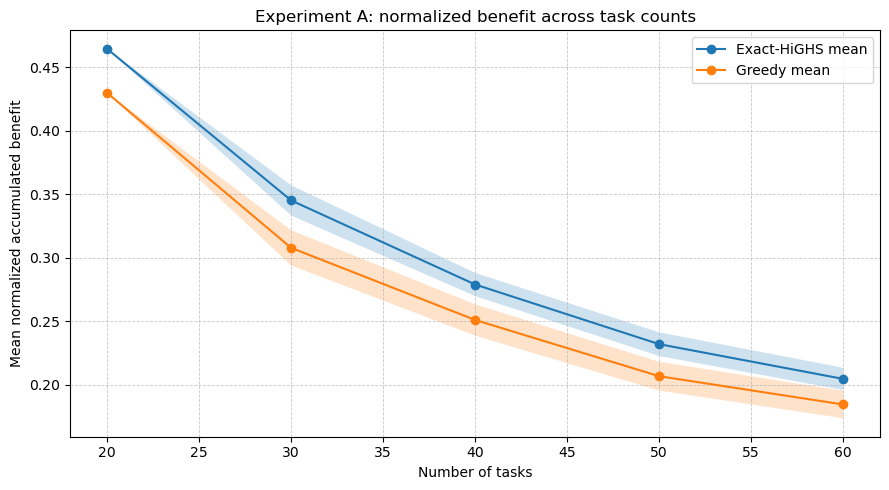

In [39]:
benefit_summary = plot_metric_mean_std(
    df_metrics_scaling,
    metric="Accumulated Benefit",
    ylabel="Mean normalized accumulated benefit",
    title="Experiment A: normalized benefit across task counts",
    methods=["Greedy", "Exact-HiGHS"],
    save_name="fig_01_benefit_mean_std.png"
)

In [16]:
# ============================================================
# PAPER-STYLE MEAN ± SD PLOT WITH INSTANCE POINTS
# ============================================================

def plot_metric_mean_std_paper(
    df_metrics,
    metric,
    ylabel,
    title,
    methods=None,
    method_labels=None,
    log_y=False,
    save_name=None,
    dpi=300,
):
    df = df_metrics.copy()

    if methods is not None:
        df = df[df["Method"].isin(methods)]

    if method_labels is None:
        method_labels = {
            "Greedy": "Greedy heuristic",
            "Exact-HiGHS": "Exact MILP (HiGHS)",
        }

    summary = (
        df
        .groupby(["Tasks", "Method"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, 5))

    method_order = methods if methods is not None else sorted(df["Method"].unique())
    offsets = np.linspace(-0.35, 0.35, len(method_order))

    min_positive = df[metric][df[metric] > 0].min()
    positive_floor = min_positive / 10 if pd.notna(min_positive) else 1e-8

    for offset, method in zip(offsets, method_order):
        raw = df[df["Method"] == method].copy()
        grouped = summary[summary["Method"] == method].sort_values("Tasks")

        x = grouped["Tasks"].to_numpy()
        y = grouped["mean"].to_numpy()
        yerr = grouped["std"].fillna(0.0).to_numpy()

        # Individual instance points
        ax.scatter(
            raw["Tasks"] + offset,
            raw[metric],
            alpha=0.35,
            s=30,
        )

        # Mean line
        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            label=f"{method_labels.get(method, method)} mean",
        )

        # ±1 SD band
        lower = y - yerr
        upper = y + yerr

        if log_y:
            lower = np.maximum(lower, positive_floor)

        ax.fill_between(
            x,
            lower,
            upper,
            alpha=0.12,
        )

    ax.set_xlabel("Number of tasks")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if log_y:
        ax.set_yscale("log")

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    ax.legend()

    # Instance annotation
    counts = (
        df.groupby(["Tasks", "Method"])
        .size()
        .reset_index(name="n")
    )

    n_min = counts["n"].min()
    n_max = counts["n"].max()

    if n_min == n_max:
        annotation = f"Points: individual instances; line: mean; band: ±1 SD; n = {n_min} per task size and method"
    else:
        annotation = f"Points: individual instances; line: mean; band: ±1 SD; n = {n_min}–{n_max} per group"

    ax.text(
        0.01,
        -0.20,
        annotation,
        transform=ax.transAxes,
        fontsize=9,
        va="top",
    )

    fig.tight_layout()

    save_current_figure(save_name=save_name, dpi=dpi)

    plt.show()

    return summary

Figure saved at: ttap_experiments_inicial/figures/fig_01_benefit_mean_std_instances.png


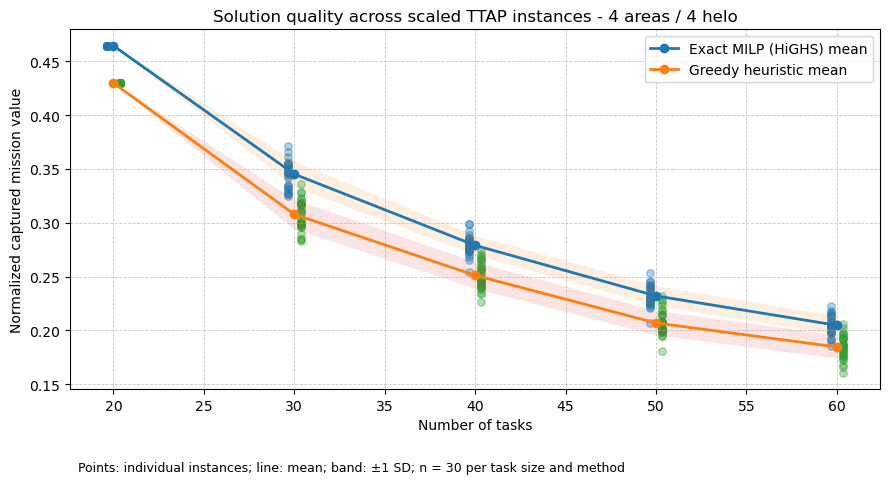

In [17]:
benefit_summary = plot_metric_mean_std_paper(
    df_metrics_scaling,
    metric="Accumulated Benefit",
    ylabel="Normalized captured mission value",
    title="Solution quality across scaled TTAP instances - 4 areas / 4 helo",
    methods=["Exact-HiGHS", "Greedy"],
    log_y=False,
    save_name="fig_01_benefit_mean_std_instances.png",
)

Figure saved at: ttap_experiments_inicial/figures/fig_02_runtime_mean_std.png


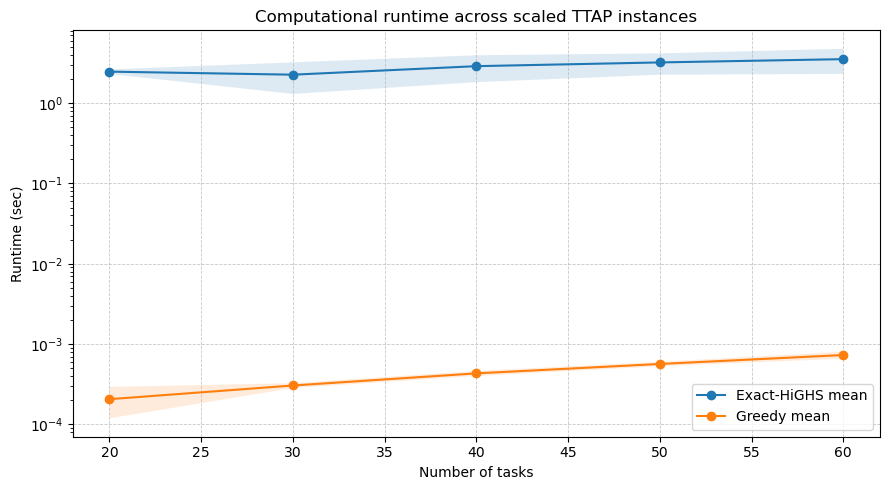

In [18]:
runtime_summary = plot_metric_mean_std(
    df_metrics_scaling,
    metric="Runtime sec",
    ylabel="Runtime (sec)",
    title="Computational runtime across scaled TTAP instances",
    methods=["Greedy", "Exact-HiGHS"],
    log_y=True,
    save_name="fig_02_runtime_mean_std.png"
)

Figure saved at: ttap_experiments_inicial/figures/fig_02_runtime_mean_std_instances.png


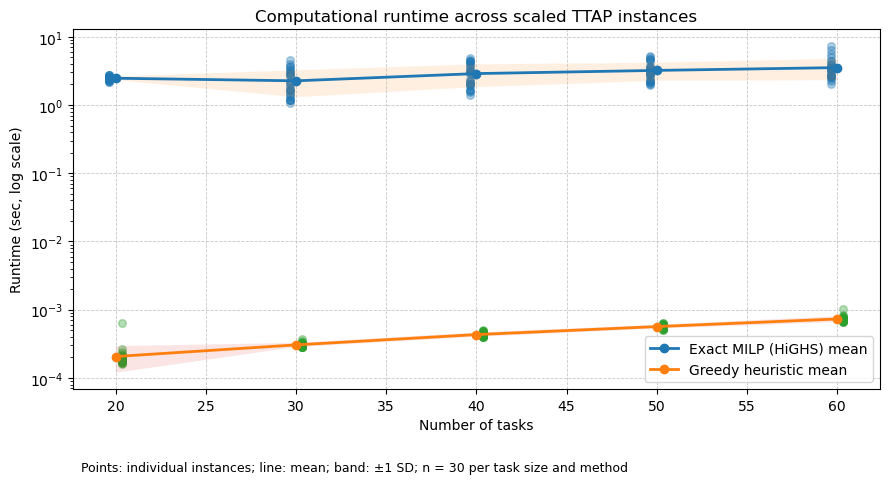

In [19]:
runtime_summary = plot_metric_mean_std_paper(
    df_metrics_scaling,
    metric="Runtime sec",
    ylabel="Runtime (sec, log scale)",
    title="Computational runtime across scaled TTAP instances",
    methods=["Exact-HiGHS", "Greedy"],
    log_y=True,
    save_name="fig_02_runtime_mean_std_instances.png",
)

In [20]:
# ============================================================
# BOXPLOT BY TASK SIZE AND METHOD
# ============================================================

def plot_metric_boxplot_by_method(
    df_metrics,
    metric,
    ylabel,
    title,
    methods=None,
    save_name=None,
    dpi=300,
):
    df = df_metrics.copy()

    if methods is not None:
        df = df[df["Method"].isin(methods)]

    tasks = sorted(df["Tasks"].dropna().unique())
    methods = sorted(df["Method"].dropna().unique())

    n_methods = len(methods)

    width = 0.7 / max(n_methods, 1)
    base_positions = np.arange(len(tasks))

    plt.figure(figsize=(10, 5))

    for m_idx, method in enumerate(methods):
        offset = (m_idx - (n_methods - 1) / 2) * width
        positions = base_positions + offset

        data = [
            df[
                (df["Tasks"] == task_size)
                & (df["Method"] == method)
            ][metric].dropna().to_numpy()
            for task_size in tasks
        ]

        plt.boxplot(
            data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=False,
            showmeans=True,
        )

    plt.xticks(base_positions, [str(t) for t in tasks])
    plt.xlabel("Number of tasks")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)

    handles = [
        plt.Line2D([0], [0], marker="s", linestyle="None", label=method)
        for method in methods
    ]

    plt.legend(handles=handles, title="Method")
    plt.tight_layout()

    save_current_figure(save_name=save_name, dpi=dpi)

    plt.show()

In [21]:
# ============================================================
# PAPER-STYLE BOXPLOT WITH INSTANCE POINTS
# ============================================================

def plot_metric_boxplot_by_method_paper(
    df_metrics,
    metric,
    ylabel,
    title,
    methods=None,
    method_labels=None,
    log_y=False,
    save_name=None,
    dpi=300,
):
    df = df_metrics.copy()

    if methods is not None:
        df = df[df["Method"].isin(methods)]

    if method_labels is None:
        method_labels = {
            "Greedy": "Greedy heuristic",
            "Exact-HiGHS": "Exact MILP (HiGHS)",
        }

    tasks = sorted(df["Tasks"].dropna().unique())
    method_order = methods if methods is not None else sorted(df["Method"].unique())

    n_methods = len(method_order)
    offsets = np.linspace(-1.2, 1.2, n_methods)
    width = 0.9

    fig, ax = plt.subplots(figsize=(10, 5))

    for offset, method in zip(offsets, method_order):
        data = []
        positions = []

        for task_size in tasks:
            values = df[
                (df["Tasks"] == task_size)
                & (df["Method"] == method)
            ][metric].dropna().to_numpy()

            data.append(values)
            positions.append(task_size + offset)

        ax.boxplot(
            data,
            positions=positions,
            widths=width,
            showmeans=False,
            patch_artist=False,
            manage_ticks=False,
        )

        # Individual points
        for task_size, values in zip(tasks, data):
            if len(values) == 0:
                continue

            jitter = np.linspace(-0.15, 0.15, len(values))
            ax.scatter(
                np.full(len(values), task_size + offset) + jitter,
                values,
                s=30,
                alpha=0.55,
                label=method_labels.get(method, method) if task_size == tasks[0] else None,
            )

    ax.set_xticks(tasks)
    ax.set_xticklabels([str(t) for t in tasks])

    ax.set_xlabel("Number of tasks")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if log_y:
        ax.set_yscale("log")

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    ax.legend(title="Method")

    counts = (
        df.groupby(["Tasks", "Method"])
        .size()
        .reset_index(name="n")
    )

    n_min = counts["n"].min()
    n_max = counts["n"].max()

    if n_min < 5:
        note = f"Boxplots are exploratory: n = {n_min} per group. Prefer mean ± SD or increase seeds for final paper."
    elif n_min == n_max:
        note = f"Points: individual instances; box: distribution; n = {n_min} per group."
    else:
        note = f"Points: individual instances; box: distribution; n = {n_min}–{n_max} per group."

    ax.text(
        0.01,
        -0.20,
        note,
        transform=ax.transAxes,
        fontsize=9,
        va="top",
    )

    fig.tight_layout()

    save_current_figure(save_name=save_name, dpi=dpi)

    plt.show()

Figure saved at: ttap_experiments_inicial/figures/fig_03_benefit_boxplot.png


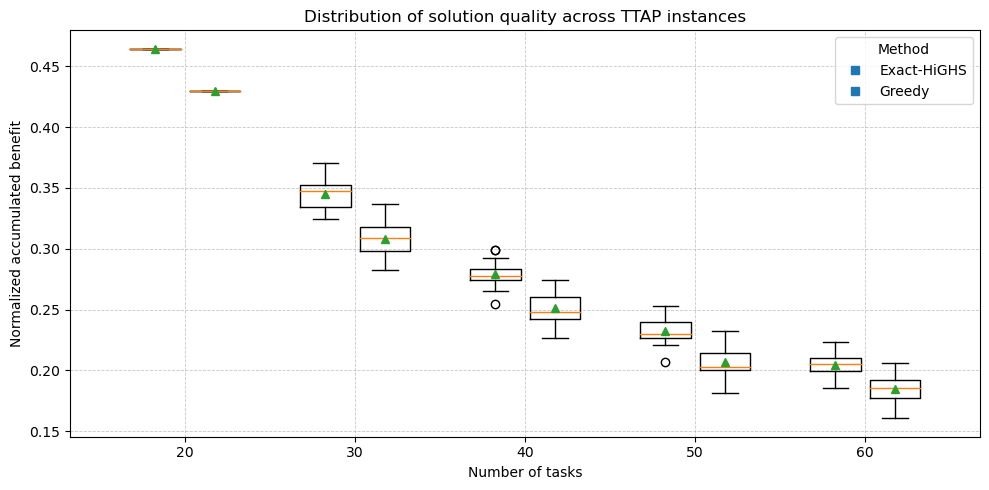

In [22]:
plot_metric_boxplot_by_method(
    df_metrics_scaling,
    metric="Accumulated Benefit",
    ylabel="Normalized accumulated benefit",
    title="Distribution of solution quality across TTAP instances",
    methods=["Greedy", "Exact-HiGHS"],
    save_name="fig_03_benefit_boxplot.png"
)

Figure saved at: ttap_experiments_inicial/figures/fig_03_benefit_boxplot_instances.png


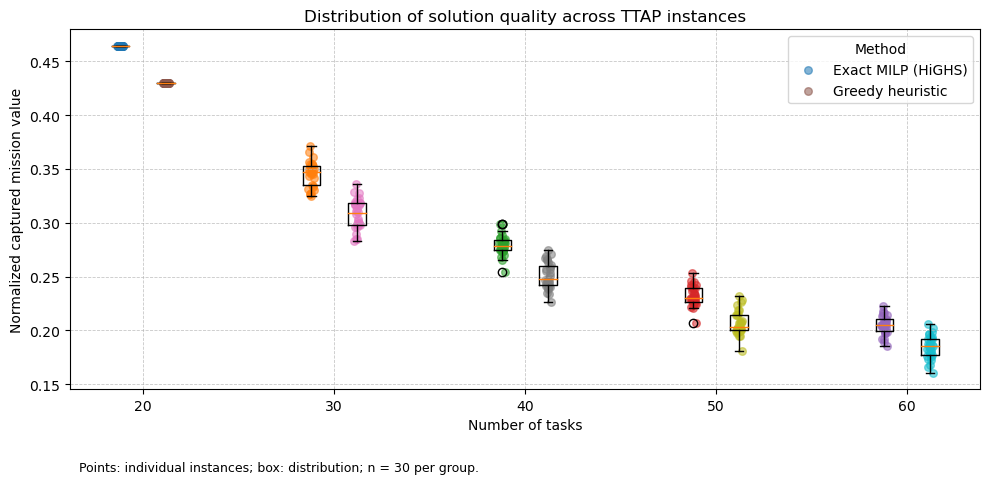

In [23]:
plot_metric_boxplot_by_method_paper(
    df_metrics_scaling,
    metric="Accumulated Benefit",
    ylabel="Normalized captured mission value",
    title="Distribution of solution quality across TTAP instances",
    methods=["Exact-HiGHS", "Greedy"],
    log_y=False,
    save_name="fig_03_benefit_boxplot_instances.png",
)

Figure saved at: ttap_experiments_inicial/figures/fig_04_runtime_boxplot.png


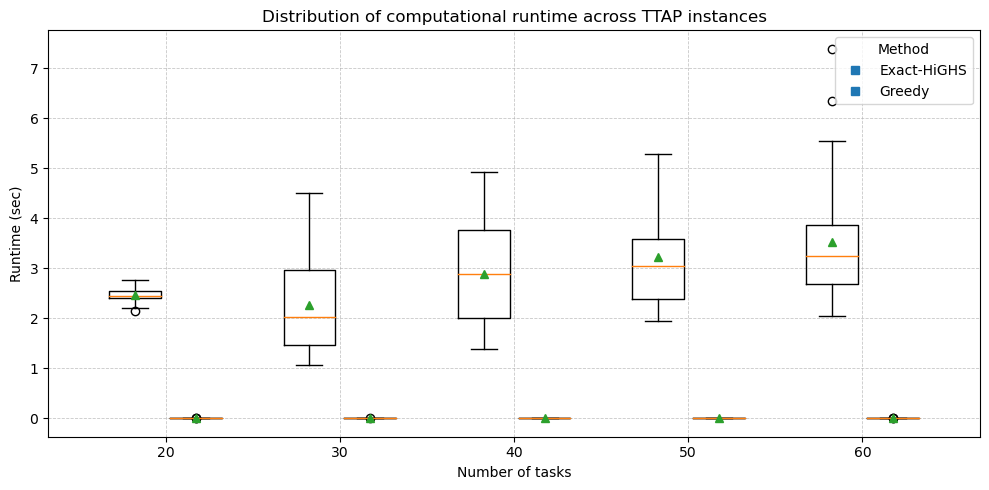

In [24]:
plot_metric_boxplot_by_method(
    df_metrics_scaling,
    metric="Runtime sec",
    ylabel="Runtime (sec)",
    title="Distribution of computational runtime across TTAP instances",
    methods=["Greedy", "Exact-HiGHS"],
    save_name="fig_04_runtime_boxplot.png"
)

Figure saved at: ttap_experiments_inicial/figures/fig_04_runtime_boxplot_instances.png


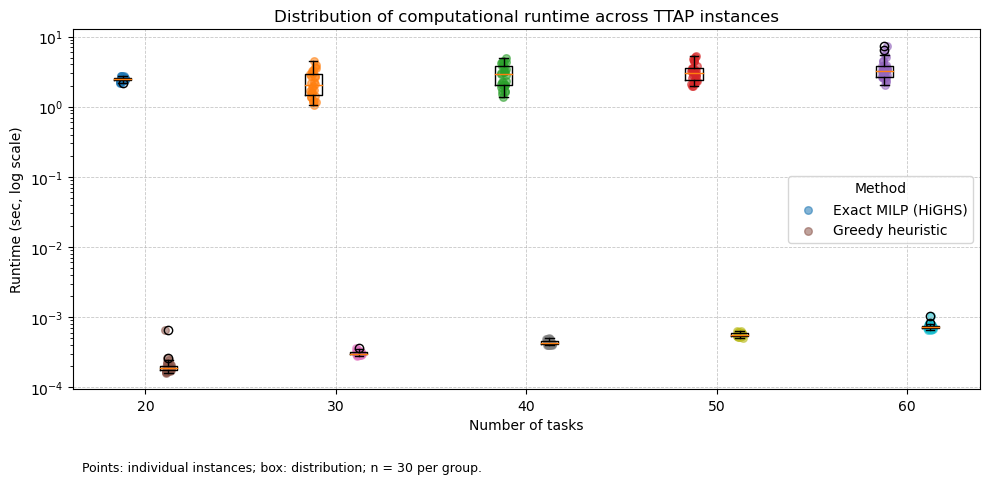

In [25]:
plot_metric_boxplot_by_method_paper(
    df_metrics_scaling,
    metric="Runtime sec",
    ylabel="Runtime (sec, log scale)",
    title="Distribution of computational runtime across TTAP instances",
    methods=["Exact-HiGHS", "Greedy"],
    log_y=True,
    save_name="fig_04_runtime_boxplot_instances.png",
)

In [26]:
# ============================================================
# TOTAL RUNTIME BY TASK SIZE FROM EXISTING RESULTS
# ============================================================

def build_total_runtime_by_size(df_metrics):
    df = df_metrics.copy()

    runtime_summary = (
        df
        .groupby(["Tasks", "Method"])
        .agg(
            Instances=("Scenario", "nunique"),
            Total_Runtime_sec=("Runtime sec", "sum"),
            Mean_Runtime_sec=("Runtime sec", "mean"),
            Std_Runtime_sec=("Runtime sec", "std"),
            Min_Runtime_sec=("Runtime sec", "min"),
            Max_Runtime_sec=("Runtime sec", "max"),
        )
        .reset_index()
    )

    return runtime_summary


runtime_total_by_method = build_total_runtime_by_size(df_metrics_scaling)

display(runtime_total_by_method)

,Tasks,Method,Instances,Total_Runtime_sec,Mean_Runtime_sec,Std_Runtime_sec,Min_Runtime_sec,Max_Runtime_sec
0,20,Exact-HiGHS,30,74.066308,2.468877,0.158067,2.144322,2.769618
1,20,Greedy,30,0.006179,0.000206,0.000087,0.000161,0.000648
2,30,Exact-HiGHS,30,67.868443,2.262281,0.959743,1.072258,4.512615
3,30,Greedy,30,0.009148,0.000305,0.000021,0.000282,0.000367
4,40,Exact-HiGHS,30,86.649887,2.888330,1.059478,1.382769,4.916067
5,40,Greedy,30,0.012952,0.000432,0.000031,0.000394,0.000500
6,50,Exact-HiGHS,30,96.455166,3.215172,0.955690,1.946223,5.287146
7,50,Greedy,30,0.016962,0.000565,0.000036,0.000506,0.000642
8,60,Exact-HiGHS,30,105.978032,3.532601,1.218458,2.048254,7.388599
9,60,Greedy,30,0.021917,0.000731,0.000072,0.000654,0.001031
